<a href="https://colab.research.google.com/github/bogiereddy/machine-learning_practice/blob/main/kmeansclustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cohesion: How close the data points are within the same cluster (lower is better).

Separation: How far apart the different clusters are from each other (higher is better).

 **clustering metrics**

**Silhouette Score**: Measures how similar a point is to its own cluster compared to other clusters.


**Davies-Bouldin Index (DBI)**: Calculates the average similarity between each cluster and its closest neighbor.

**Calinski-Harabasz Index:**
Calculates the ratio of between-cluster dispersion to within-cluster dispersion.


In [15]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns



**min max scale:**
 Current value-MinValue/MaximumValue -Minimum Value

In [6]:
df=pd.read_csv("/content/income.csv")

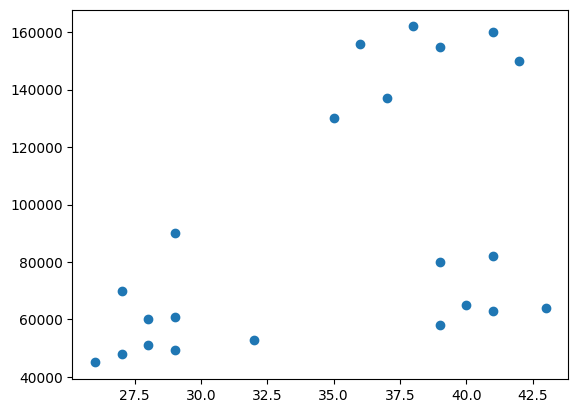

In [9]:
plt.scatter(df["Age"],df["Income($)"])

In [17]:
k=KMeans(n_clusters=3)
k


KMeans(n_clusters=3)

In [18]:
y_predict =k.fit_predict(df[['Age','Income($)']])

In [20]:
y_predict

array([0, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0],
      dtype=int32)

In [21]:
df['cluter'] = y_predict
df.head()

,Name,Age,Income($),cluter
0,Rob,27,70000,0
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


/tmp/ipykernel_12539/3045073901.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


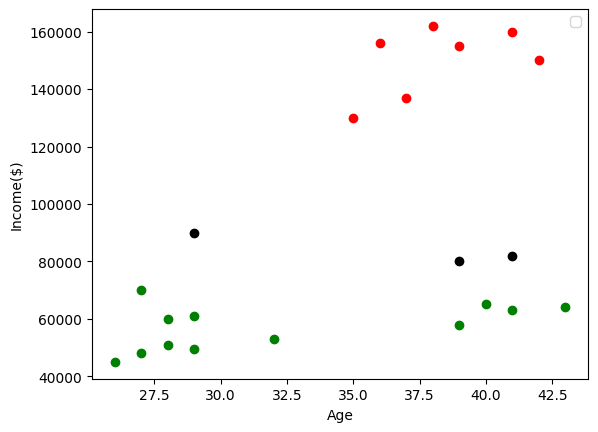

In [24]:
df1=df[df.cluter==0]
df2=df[df.cluter==1]
df3=df[df.cluter==2]

plt.scatter(df1.Age,df1['Income($)'],color='green')
plt.scatter(df2.Age,df2['Income($)'],color='red')
plt.scatter(df3.Age,df3['Income($)'],color='black')
#plt.scatter(k.cluster_centers_[:,0],k.cluster_centers_[:,1],color='purple',marker='*',label='centroid')

plt.xlabel('Age')
plt.ylabel('Income($)')
plt.legend()


In [27]:
scaler=MinMaxScaler()
scaler.fit(df[['Income($)']])
df['Income($)']=scaler.transform(df[['Income($)']])
scaler.fit(df[['Age']])
df['Age']=scaler.transform(df[['Age']])
df.head(5)

,Name,Age,Income($),cluter
0,Rob,0.058824,0.213675,0
1,Michael,0.176471,0.384615,2
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1


In [28]:
km=KMeans(n_clusters=3)
y_predicted=km.fit_predict(df[['Age','Income($)']])


,Name,Age,Income($),cluter,cluster
0,Rob,0.058824,0.213675,0,0
1,Michael,0.176471,0.384615,2,0
2,Mohan,0.176471,0.136752,0,0
3,Ismail,0.117647,0.128205,0,0
4,Kory,0.941176,0.897436,1,1


In [30]:
df['cluster']=y_predicted
df.drop('cluter',axis='columns', inplace= True)
df.head()

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,0
1,Michael,0.176471,0.384615,0
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1


/tmp/ipykernel_12539/2566177903.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


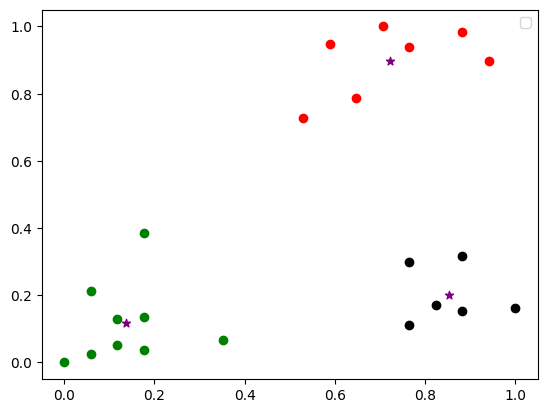

In [33]:
df1=df[df.cluster==0]
df2=df[df.cluster==1]
df3=df[df.cluster==2]

plt.scatter(df1.Age,df1['Income($)'],color='green')
plt.scatter(df2.Age,df2['Income($)'],color='red')
plt.scatter(df3.Age,df3['Income($)'],color='black')
plt.legend()
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')

In [34]:
#elbow method
k_range=range(1,10)
sse=[]
for k in k_range:
  km=KMeans(n_clusters=k)
  km.fit(df[['Age','Income($)']])
  sse.append(km.inertia_)


In [35]:
sse

[5.434011511988176,
 2.0911363886990766,
 0.4750783498553095,
 0.3491047094419565,
 0.3170679618298384,
 0.24591705034877778,
 0.17462386586687892,
 0.13762504146528043,
 0.11436926579512273]

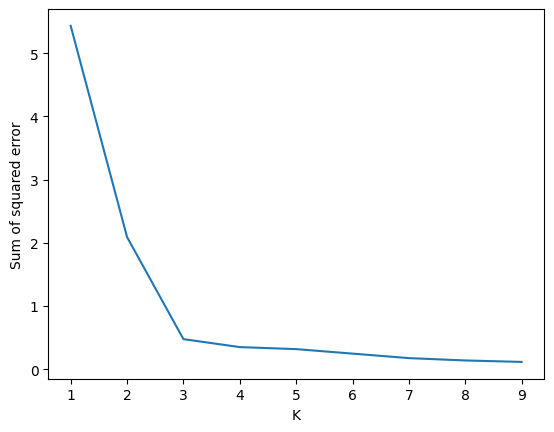

In [36]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_range,sse)
